<a href="https://colab.research.google.com/github/sajivjose174/Project/blob/main/Loantap_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LoanTap Logistic Regression:
LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind,chi2_contingency

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay,f1_score,recall_score,precision_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
!curl -L -o logistic_regression.csv "https://drive.google.com/uc?export=download&id=1ZPYj7CZCfxntE8p2Lze_4QO4MyEOy6_d"
lt_data =pd.read_csv('logistic_regression.csv')
df = lt_data.copy()
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 95.7M  100 95.7M    0     0  14.0M      0  0:00:06  0:00:06 --:--:-- 21.7M


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [ ]:
df.shape

(396030, 27)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')

#Statisctal Summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,396030.0,14113.888089,8357.441341,500.00,8000.00,12000.00,20000.00,40000.00
int_rate,396030.0,13.639400,4.472157,5.32,10.49,13.33,16.49,30.99
installment,396030.0,431.849698,250.727790,16.08,250.33,375.43,567.30,1533.81
annual_inc,396030.0,74203.175798,61637.621158,0.00,45000.00,64000.00,90000.00,8706582.00
dti,396030.0,17.379514,18.019092,0.00,11.28,16.91,22.98,9999.00
open_acc,396030.0,11.311153,5.137649,0.00,8.00,10.00,14.00,90.00
pub_rec,396030.0,0.178191,0.530671,0.00,0.00,0.00,0.00,86.00
revol_bal,396030.0,15844.539853,20591.836109,0.00,6025.00,11181.00,19620.00,1743266.00
revol_util,395754.0,53.791749,24.452193,0.00,35.80,54.80,72.90,892.30
total_acc,396030.0,25.414744,11.886991,2.00,17.00,24.00,32.00,151.00


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
term,396030,2,36 months,302005
grade,396030,7,B,116018
sub_grade,396030,35,B3,26655
emp_title,373103,173105,Teacher,4389
emp_length,377729,11,10+ years,126041
home_ownership,396030,6,MORTGAGE,198348
verification_status,396030,3,Verified,139563
issue_d,396030,115,Oct-2014,14846
loan_status,396030,2,Fully Paid,318357
purpose,396030,14,debt_consolidation,234507


#duplicate detection

In [ ]:
#duplicates:
df[df.duplicated()]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address


#null detection

In [ ]:
df.isna().any()[df.isna().any()]

,0
emp_title,True
emp_length,True
title,True
revol_util,True
mort_acc,True
pub_rec_bankruptcies,True


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
mort_acc,37795
emp_title,22927
emp_length,18301
title,1756
pub_rec_bankruptcies,535
revol_util,276
installment,0
int_rate,0
term,0
grade,0


In [ ]:
def missing_data(df):
    total_missing_df = df.isnull().sum().sort_values(ascending =False)
    percent_missing_df = (df.isnull().sum()/df.isna().count()*100).sort_values(ascending=False)
    missing_data_df = pd.concat([total_missing_df, percent_missing_df], axis=1, keys=['Total', 'Percent'])
    return missing_data_df

missing_pct = missing_data(df)
missing_pct[missing_pct['Total']>0]

,Total,Percent
mort_acc,37795,9.543469
emp_title,22927,5.789208
emp_length,18301,4.621115
title,1756,0.443401
pub_rec_bankruptcies,535,0.135091
revol_util,276,0.069692


In [ ]:
df.isna().sum().sum()

np.int64(81590)

In [ ]:
#since there are 81590 rows are null , we cant drop

In [ ]:
#checking the unique values for columns
for _ in df.columns:
    print()
    print(f'Total Unique Values in {_} column are :- {df[_].nunique()}')
    print(f'Unique Values in {_} column are :-\n {df[_].unique()}')
    print(f'Value_counts of {_} column :-\n {df[_].value_counts()}')
    print()
    print('-'*120)


Total Unique Values in loan_amnt column are :- 1397
Unique Values in loan_amnt column are :-
 [10000.  8000. 15600. ... 36275. 36475.   725.]
Value_counts of loan_amnt column :-
 loan_amnt
10000.0    27668
12000.0    21366
15000.0    19903
20000.0    18969
35000.0    14576
           ...  
39200.0        1
38750.0        1
36275.0        1
36475.0        1
725.0          1
Name: count, Length: 1397, dtype: int64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in term column are :- 2
Unique Values in term column are :-
 [' 36 months' ' 60 months']
Value_counts of term column :-
 term
36 months    302005
60 months     94025
Name: count, dtype: int64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in int_rate column are :- 566
Unique Values in int_rate column are :-
 [11.44 11.99 10.49  6.49 17.27 13.

#Null Treatment:

In [ ]:
df.loc[df['revol_util'].isna(),'revol_util'] = 0.0
df.loc[df['mort_acc'].isna(),'mort_acc'] = 0.0
df.loc[df['pub_rec_bankruptcies'].isna(),'pub_rec_bankruptcies'] = 0.0
df.loc[df['emp_title'].isna(),'emp_title'] = 'No Employee Title'
df.loc[df['title'].isna(),'title'] = 'Unavailable'
df['emp_length'] = df['emp_length'].fillna('< 1 year')

In [ ]:
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,0
emp_length,0
home_ownership,0
annual_inc,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,396030.0,14113.888089,8357.441341,500.00,8000.00,12000.00,20000.00,40000.00
int_rate,396030.0,13.639400,4.472157,5.32,10.49,13.33,16.49,30.99
installment,396030.0,431.849698,250.727790,16.08,250.33,375.43,567.30,1533.81
annual_inc,396030.0,74203.175798,61637.621158,0.00,45000.00,64000.00,90000.00,8706582.00
dti,396030.0,17.379514,18.019092,0.00,11.28,16.91,22.98,9999.00
open_acc,396030.0,11.311153,5.137649,0.00,8.00,10.00,14.00,90.00
pub_rec,396030.0,0.178191,0.530671,0.00,0.00,0.00,0.00,86.00
revol_bal,396030.0,15844.539853,20591.836109,0.00,6025.00,11181.00,19620.00,1743266.00
revol_util,396030.0,53.754260,24.484857,0.00,35.80,54.80,72.90,892.30
total_acc,396030.0,25.414744,11.886991,2.00,17.00,24.00,32.00,151.00


#Feature Engg.

In [ ]:
df['pub_rec'] = [1 if i > 1 else 0 for i in df['pub_rec']]
df['mort_acc'] = [1 if i > 1 else 0 for i in df['mort_acc']]
df['pub_rec_bankruptcies'] = [1 if i > 1 else 0 for i in df['pub_rec_bankruptcies']]

In [ ]:
#Split issue_date into month and year
df[['issue_month', 'issue_year']] = df['issue_d'].str.split('-', expand=True)
df.drop(['issue_d'], axis=1, inplace=True)

In [ ]:
#Split er_cr_line date into month and year
df[['er_cr_line_m', 'er_cr_line_y']] = df['earliest_cr_line'].str.split('-', expand=True)
df.drop(['earliest_cr_line'], axis=1, inplace=True)

In [ ]:
#Split address into State and Zip code
import re
df[['state','zipcode']] = df['address'].str.extract(r'([A-Z]{2}) (\d{5})')
df.drop(['address'], axis=1, inplace=True)

In [ ]:
df['emp_length_yrs'] = df['emp_length'].str.extract('(\d+)')
df.drop(['emp_length'], axis=1, inplace=True)

In [ ]:
df['term'] = df['term'].str.split().str[0].astype('object')

In [ ]:
# List of categorical columns
cat_cols = df.select_dtypes(include='object')

# List of numerical columns
num_cols = df.select_dtypes(exclude='object')

In [ ]:
cat_cols.sample(3)

,term,grade,sub_grade,emp_title,home_ownership,verification_status,loan_status,purpose,title,initial_list_status,application_type,issue_month,issue_year,er_cr_line_m,er_cr_line_y,state,zipcode,emp_length_yrs
86481,36,C,C3,Clinton Public Schools,MORTGAGE,Not Verified,Fully Paid,credit_card,Eliminating CC Debt,f,INDIVIDUAL,Jul,2013,Oct,1999,MI,48052,10
137664,36,C,C4,clerk,OWN,Source Verified,Fully Paid,credit_card,Credit card refinancing,w,INDIVIDUAL,Apr,2015,Apr,2004,NE,30723,10
305012,36,D,D1,System Administrator,RENT,Not Verified,Charged Off,debt_consolidation,Debt consolidation,w,INDIVIDUAL,Nov,2014,Oct,1999,DC,48052,1


In [ ]:
num_cols.sample(3)

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
245081,6600.0,14.64,227.63,55000.0,12.66,8.0,0,2424.0,59.0,34.0,1,0
93302,12600.0,19.99,333.76,35000.0,13.65,4.0,0,6430.0,83.5,11.0,0,0
102302,21075.0,9.67,676.78,240000.0,9.34,8.0,0,26117.0,82.9,17.0,1,0


In [ ]:
# List of categorical columns
cat_cols = df.select_dtypes(include='object')

# List of numerical columns
num_cols = df.select_dtypes(exclude='object')

In [ ]:
num_cols.skew()

,0
loan_amnt,0.777285
int_rate,0.420669
installment,0.983598
annual_inc,41.042725
dti,431.051225
open_acc,1.213019
pub_rec,6.812303
revol_bal,11.727515
revol_util,-0.074238
total_acc,0.864328


Observation:
Features are Right skewed.

Solution:
Need to apply log transformations in order to normalise them

In [ ]:
#Features are Right skewed

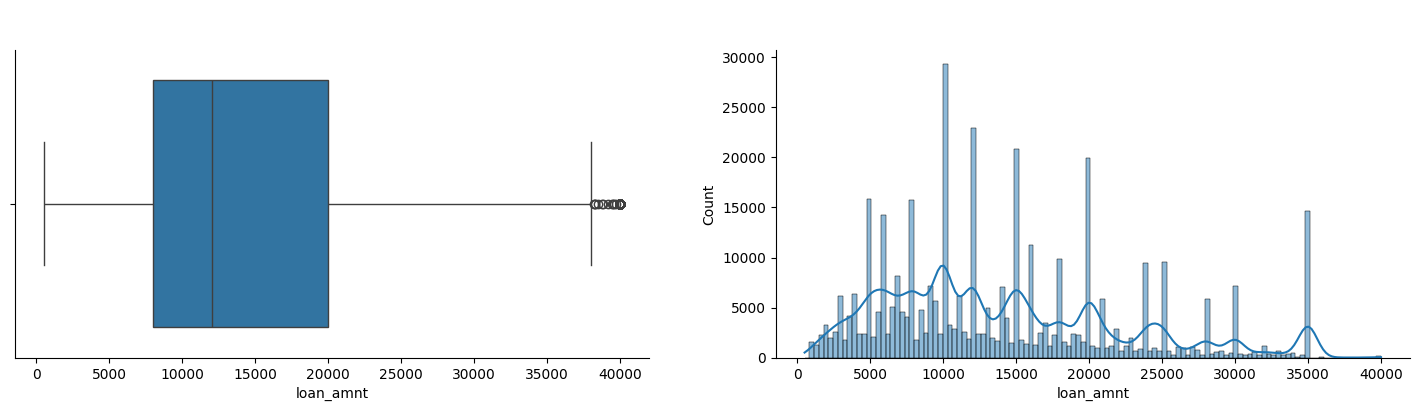

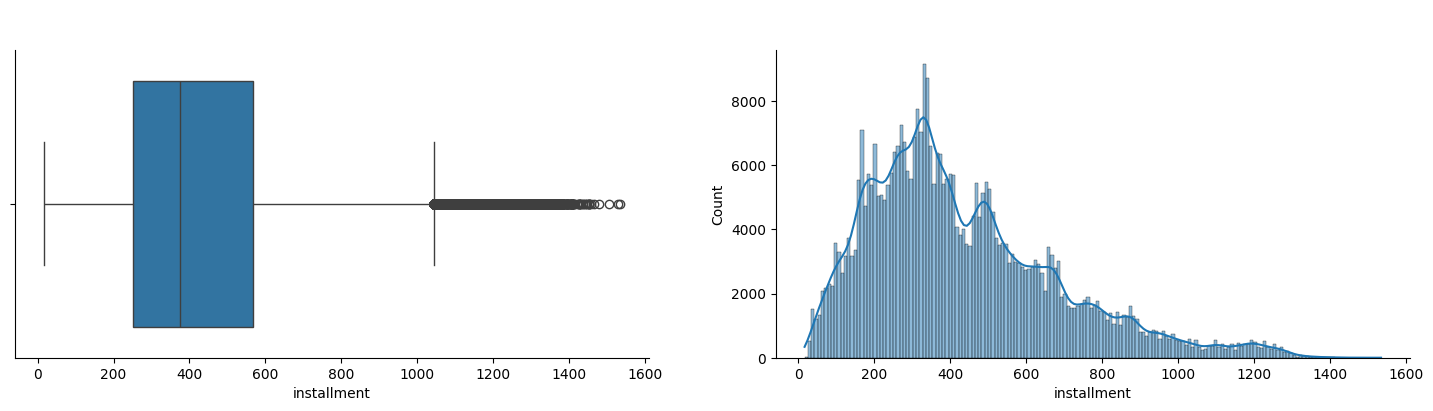

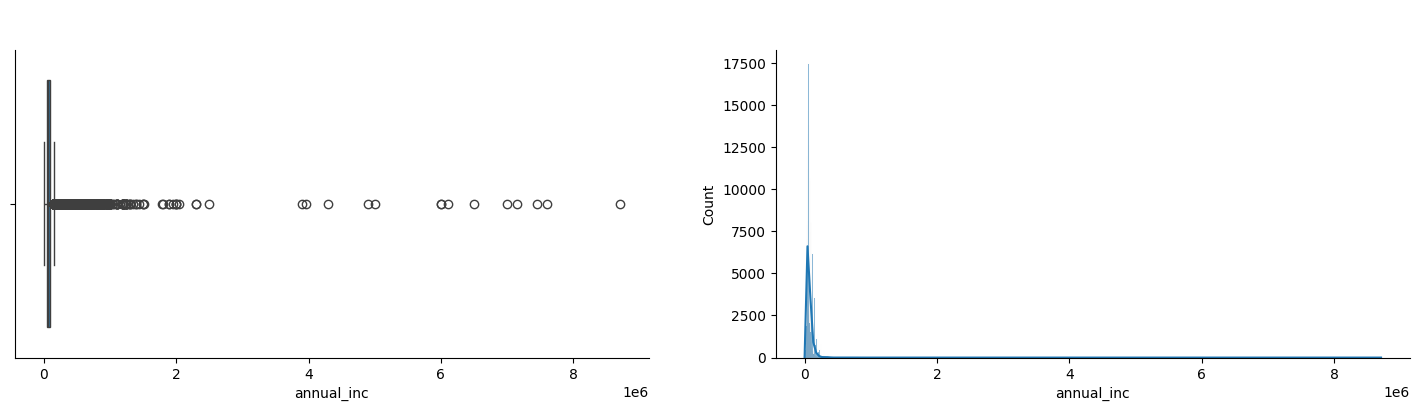

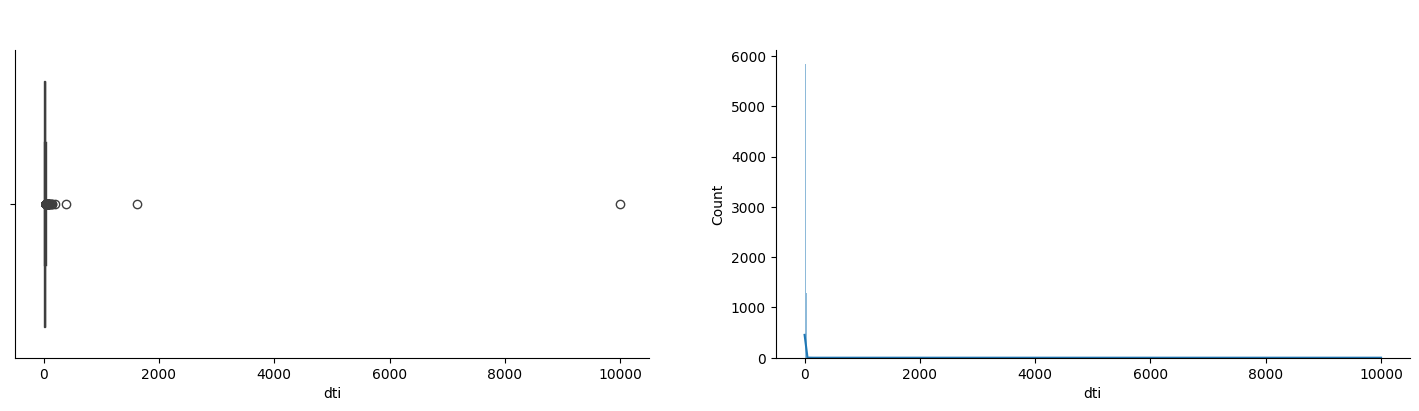

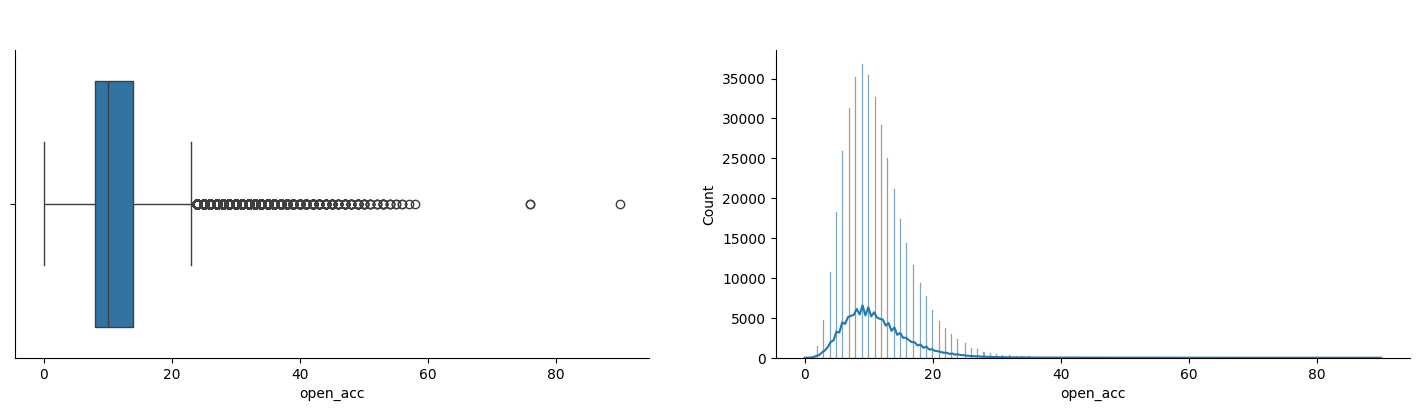

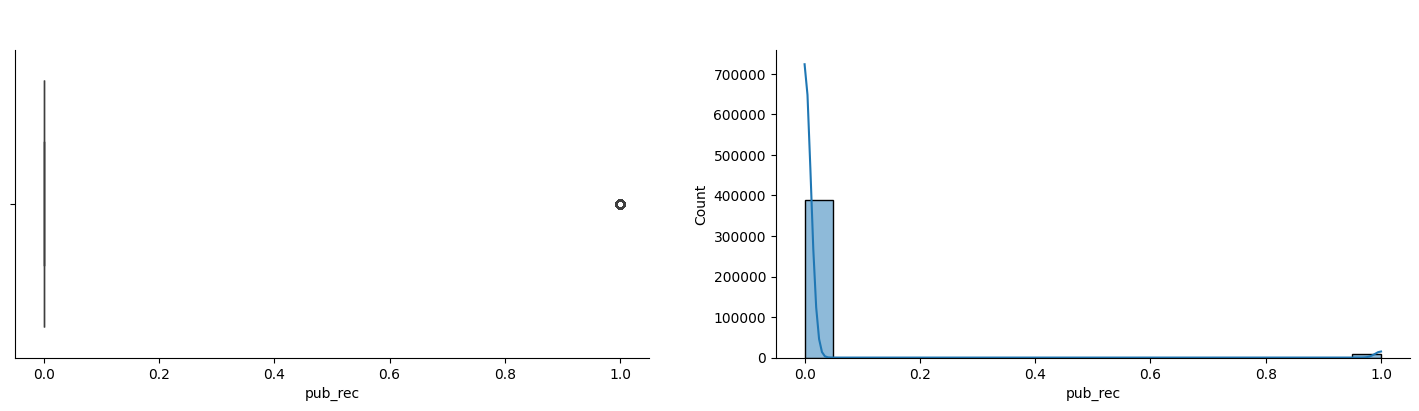

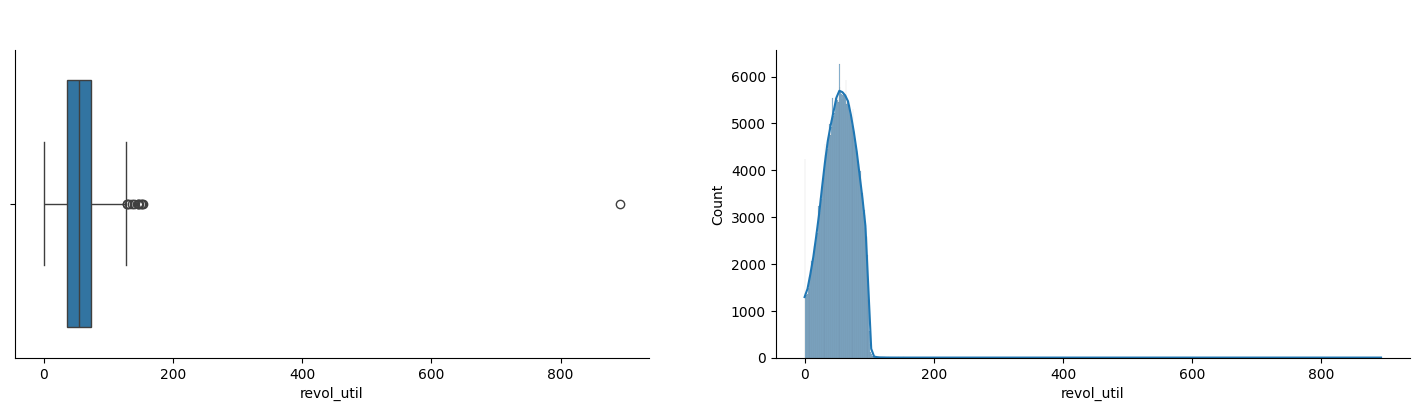

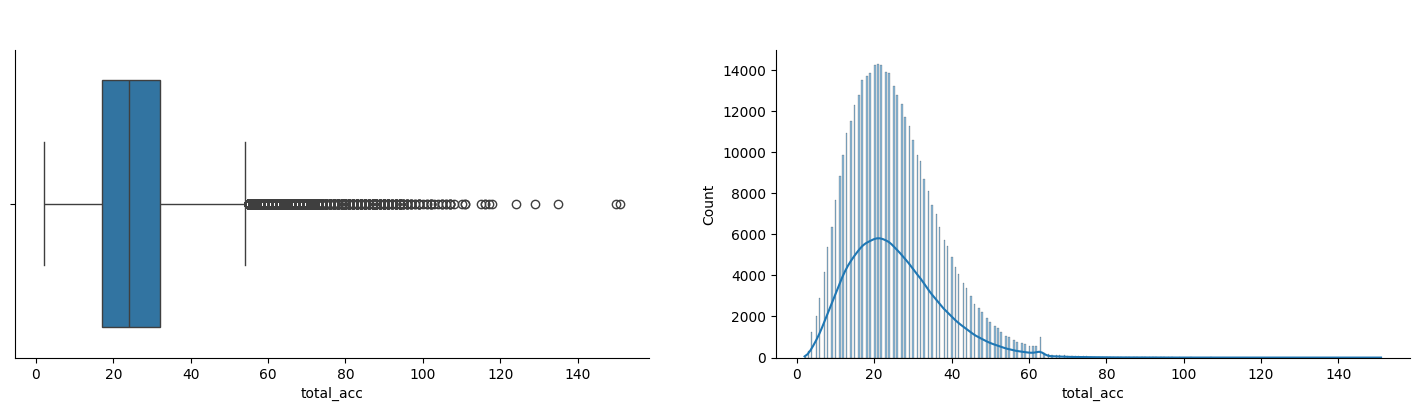

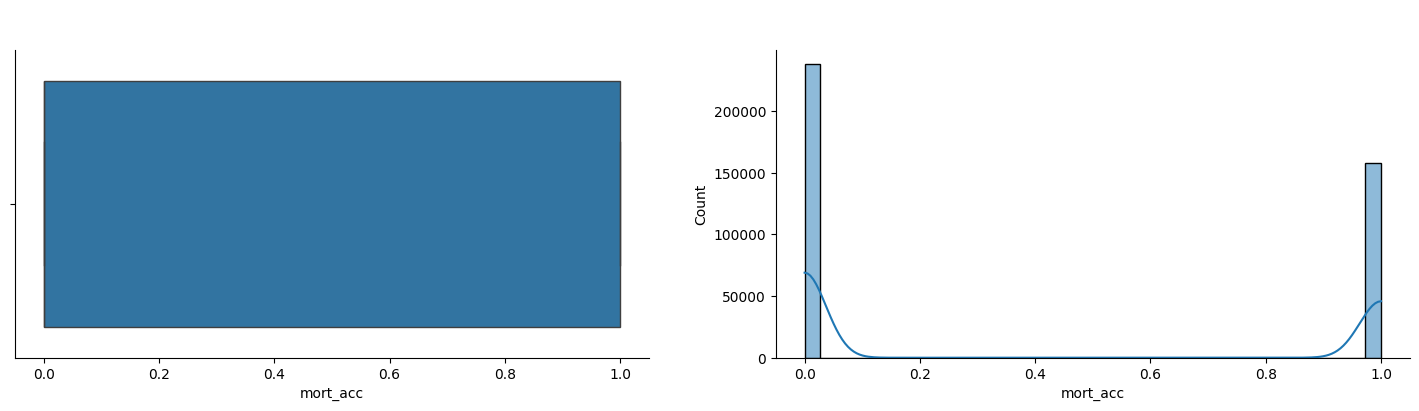

In [ ]:
plt.style.use('default')
outlier_graphical_cols = num_cols.iloc[:,[0,2,3,4,5,6,8,9,10]]
for _,col in enumerate(outlier_graphical_cols.columns):
    plt.figure(figsize=(18,4))
    plt.suptitle(f'plot of {col}',fontsize=15,fontfamily='serif',fontweight='bold',color='w')
    plt.subplot(121)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
    plt.subplot(122)
    sns.histplot(x=df[col], kde=True)
    plt.title(f'Distplot of {col}',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
    sns.despine()
    plt.show()

Observation

*   The analysis suggests a presence of outliers, prompting further investigation into outlier detection techniques.
*   features such as Pub_rec, Mort_acc, and Pub_rec_bankruptcies display a sparse distribution of unique values, indicating the potential benefit of generating binary features from these variables



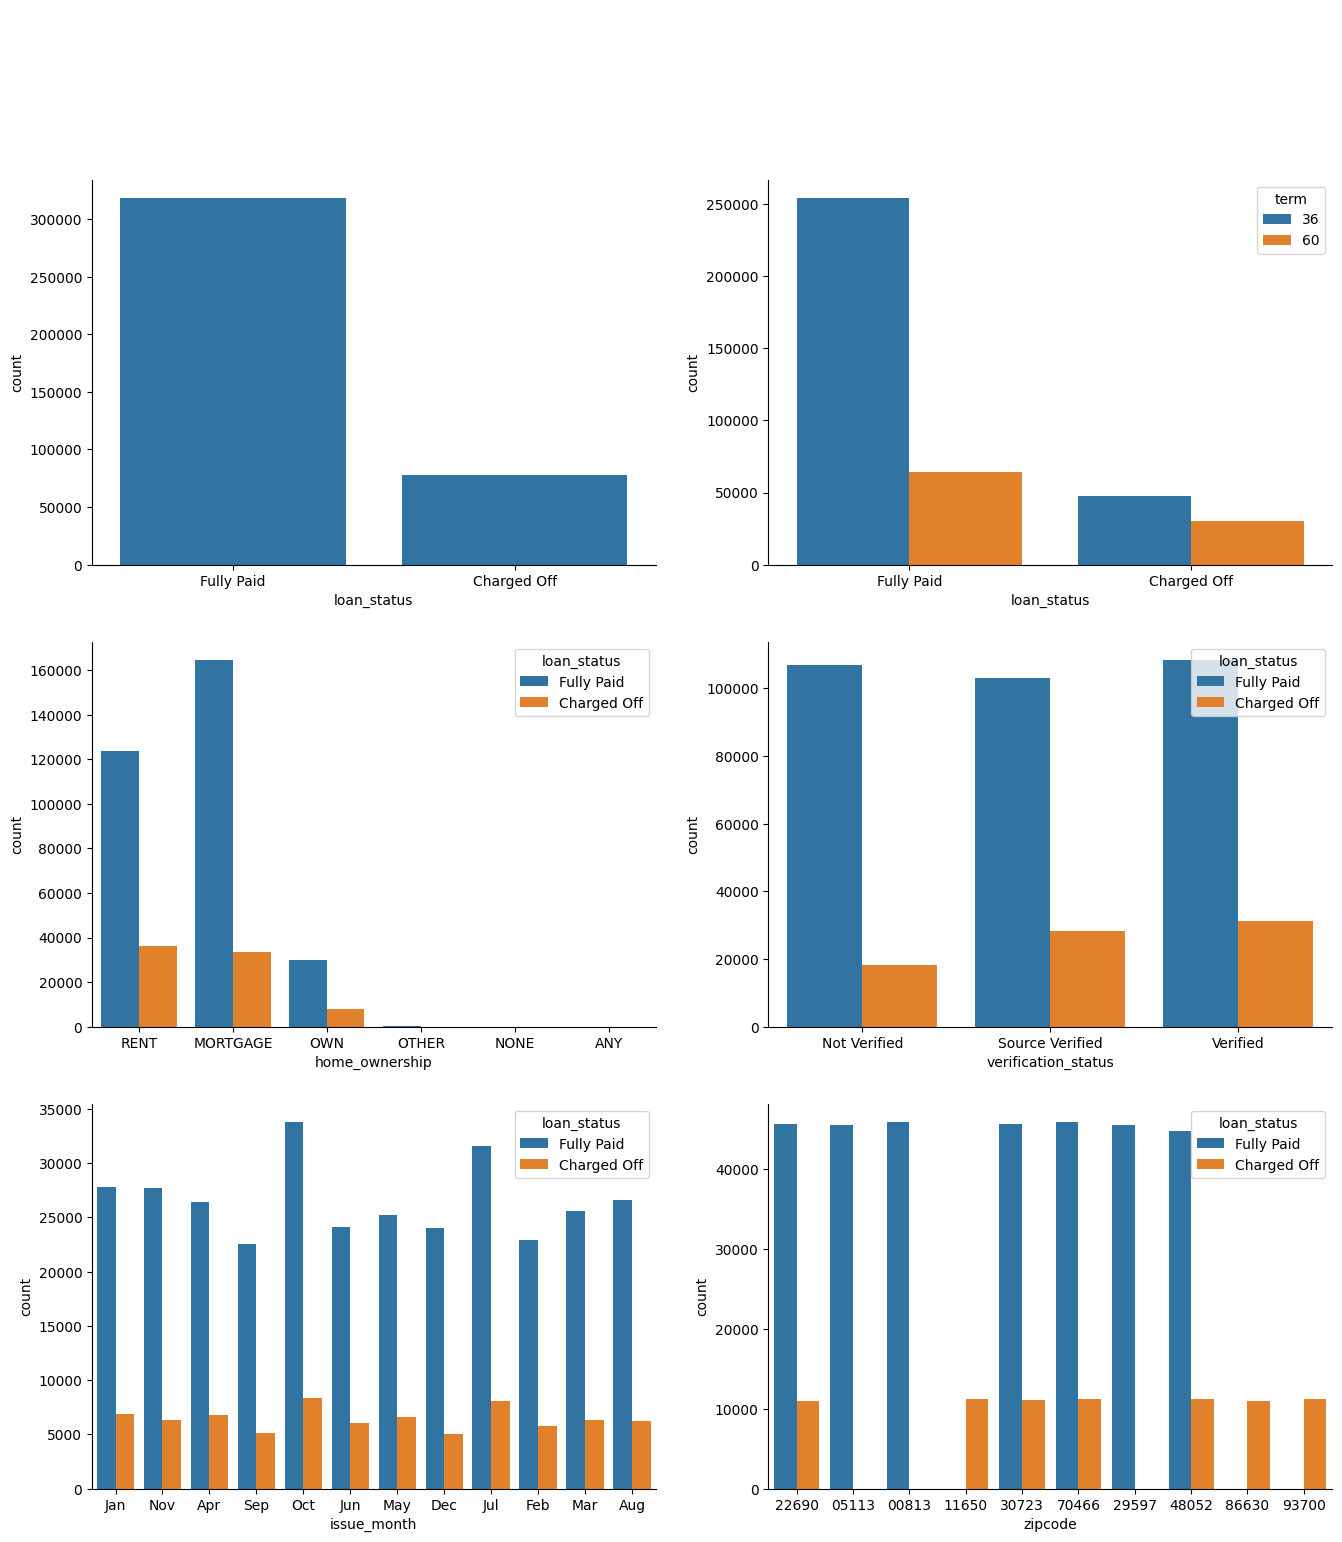

In [ ]:
#Countplots of various categorical features w.r.t. to target variable loan_status
plt.figure(figsize=(16,17))
plt.suptitle('Countplots of various categorical features w.r.t. to target variable loan_status',
             fontsize=14,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(321)
sns.countplot(data=df, x='loan_status')
plt.title('Loan Status Counts',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(322)
sns.countplot(data=df, x='loan_status', hue='term')
plt.title('Term wise loan status count',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(323)
sns.countplot(data=df, x='home_ownership', hue='loan_status')
plt.title('Loan Status Vs Home Ownership',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(324)
sns.countplot(data=df, x='verification_status', hue='loan_status')
plt.title('Loan Status Vs Verification Status',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(325)
sns.countplot(data=df, x='issue_month', hue='loan_status')
plt.title('Loan Status Vs issue_month',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(326)
sns.countplot(data=df, x='zipcode', hue='loan_status')
plt.title('Loan Status Vs zipcode',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
sns.despine()
plt.show()

It's been observed that loans have been completely charged off in zip codes 11650, 86630, and 93700.

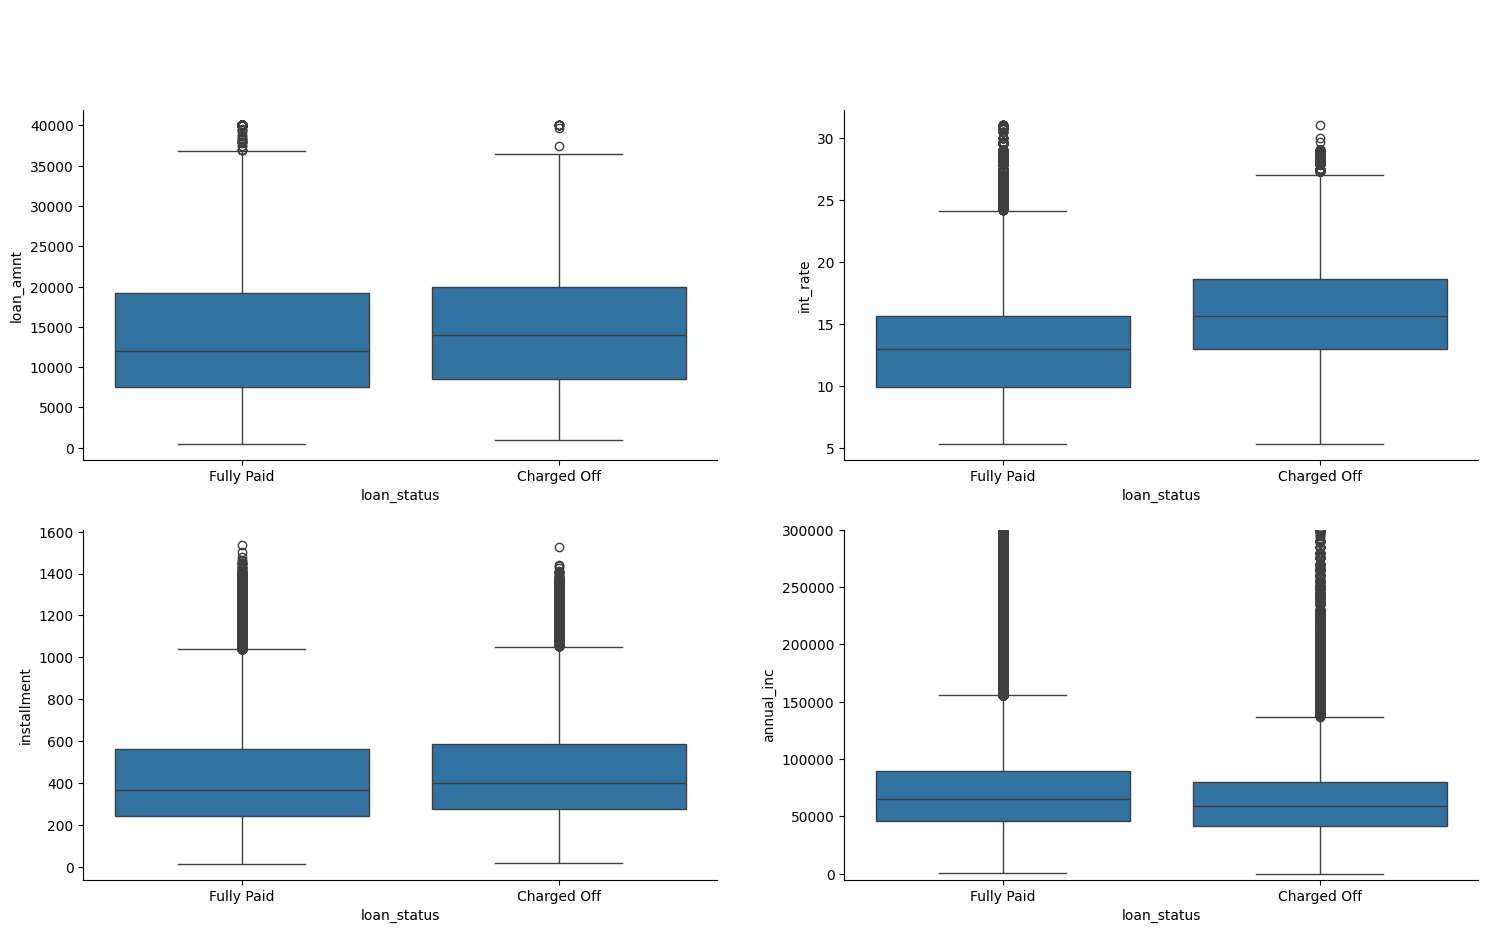

In [ ]:
#Boxplot of various cont. features w.r.t. target variable loan_status
plt.figure(figsize=(18,10))
plt.suptitle('Boxplot of various cont. features w.r.t. target variable loan_status',
             fontsize=14,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(221)
sns.boxplot(data=df, x='loan_status', y='loan_amnt')
plt.title('Loan Status Vs Loan amounts',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(222)
sns.boxplot(data=df, x='loan_status', y='int_rate')
plt.title('Loan Status Vs Interest Rate ',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(223)
sns.boxplot(data=df, x='loan_status', y='installment')
plt.title('Loan Status Vs EMI',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(224)
sns.boxplot(data=df, x='loan_status', y='annual_inc')
plt.ylim(bottom=-5000, top=300000)
plt.title('Loan Status Vs Annual Income',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
sns.despine()
plt.show()

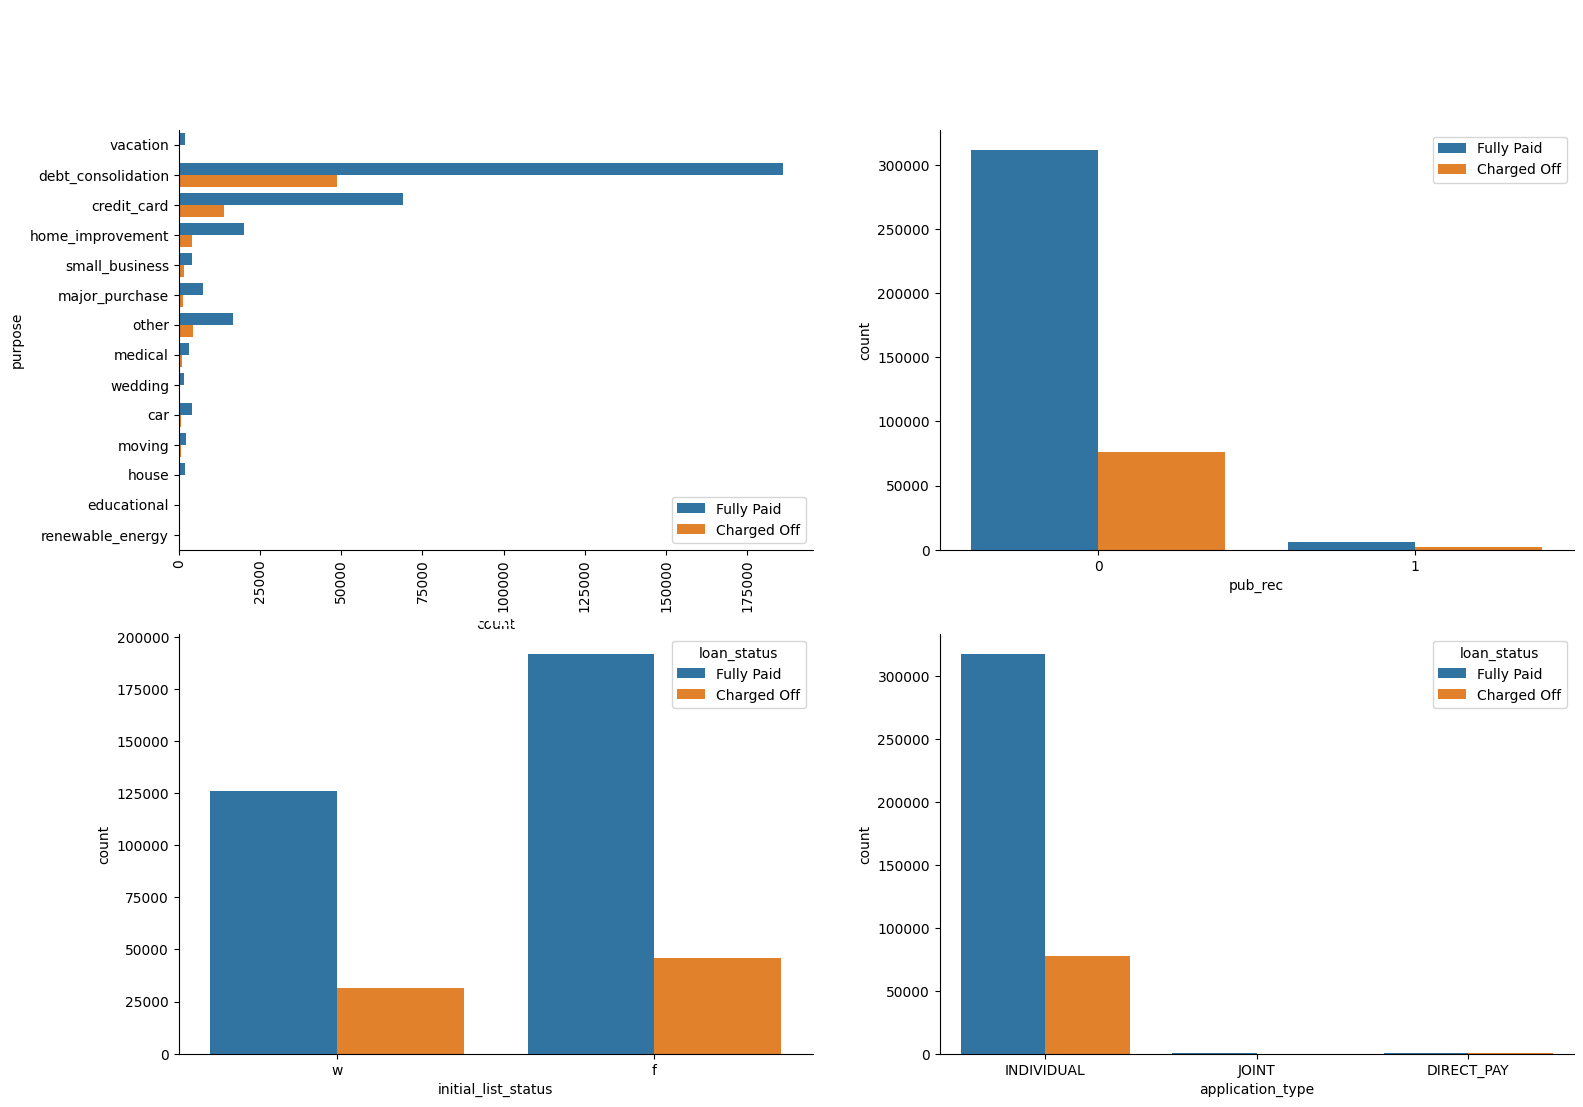

In [ ]:
#Countplot of categorical variables w.r.t. target variable loan_status
plt.figure(figsize=(18,12))
plt.suptitle('Countplot of categorical variables w.r.t. target variable loan_status',
             fontsize=14,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(221)
sns.countplot(data=df, y='purpose', hue='loan_status')
plt.xticks(rotation=90)
plt.title('Loan Status Vs Loan Purpose',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.legend(loc=4)
plt.subplot(222)
sns.countplot(data=df, x='pub_rec',hue='loan_status')
plt.title('Loan Status Vs Public Records Open',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.legend(loc=1)
plt.subplot(223)
sns.countplot(data=df, x='initial_list_status', hue='loan_status')
plt.title('Loan Status Vs Initial List Status',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(224)
sns.countplot(data=df, x='application_type',hue='loan_status')
plt.title('Loan Status Vs Application Type',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
sns.despine()
plt.show()

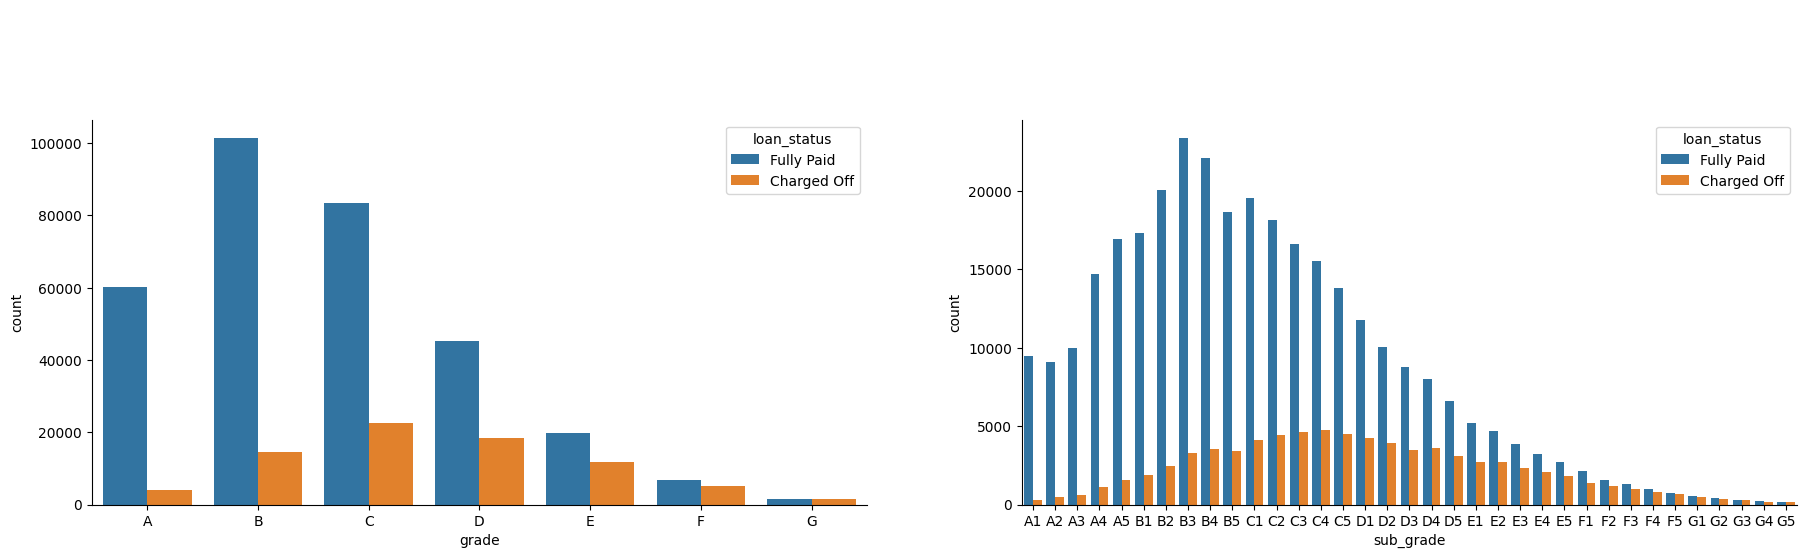

In [ ]:
plt.figure(figsize=(22,11))
plt.suptitle('Countplot of categorical variables w.r.t. target variable loan_status',
             fontsize=14,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(221)
grade = sorted(df.grade.unique().tolist())
sns.countplot(x='grade', data=df, hue='loan_status', order=grade)
plt.title('Grade vs loan_status',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(222)
sub_grade = sorted(df.sub_grade.unique().tolist())
sns.countplot(x='sub_grade', data=df, hue='loan_status', order=sub_grade)
plt.title('Sub_Grade vs loan_status',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
sns.despine()
plt.show()

Observation:

- Top 2 loan purpose categories are Debit Consolidation and Credit Card
- Topmost loan type application is INDIVIDUAL
- The distribution of open_acc appears to be relatively normal when visualized graphically.
- Charged Off and Fully Paid categories exhibit similar distributions.

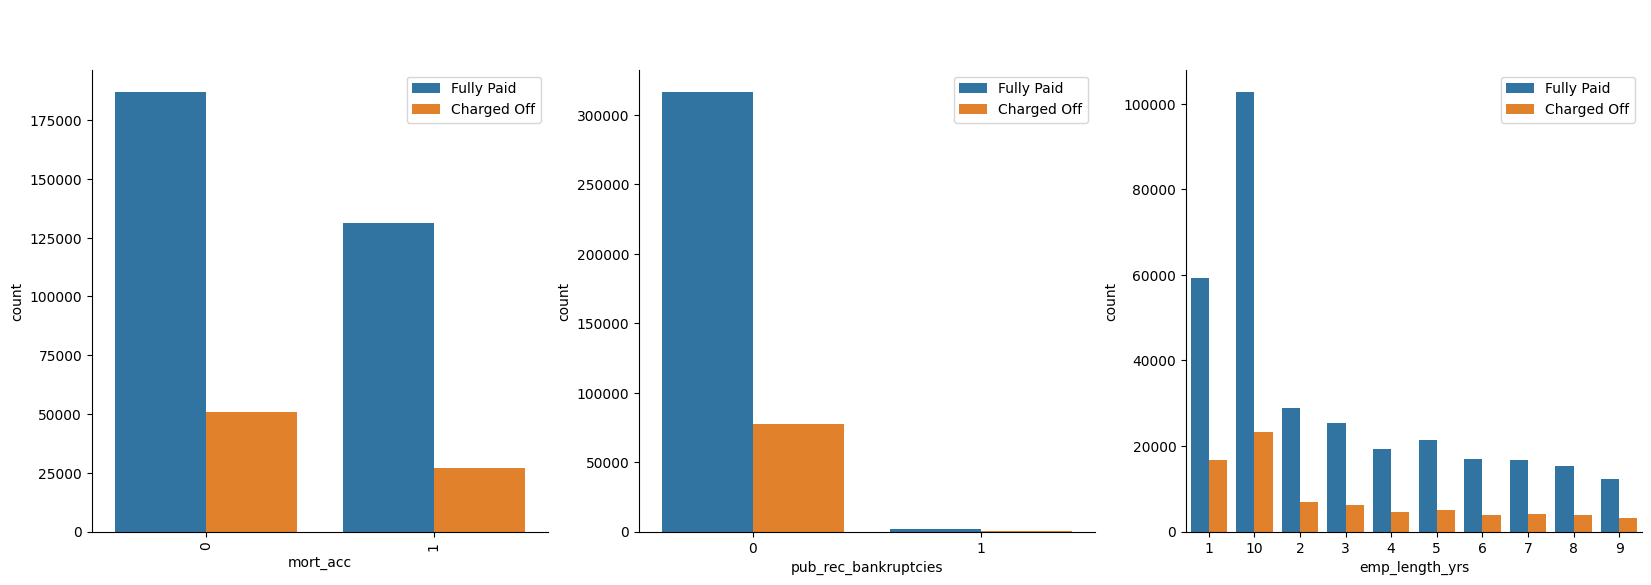

In [ ]:
#Countplot for various categorical features w.r.t. target variable loan_status

plt.figure(figsize=(20,6))
plt.suptitle('Countplot of categorical variables w.r.t. target variable loan_status',
             fontsize=14,fontfamily='serif',fontweight='bold',color='w')
plt.subplot(131)
sns.countplot(data=df, x='mort_acc',hue='loan_status')
plt.xticks(rotation=90)
plt.title('Loan Status Vs Number of mortgage accounts',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.legend(loc=1)
plt.subplot(132)
sns.countplot(data=df, x='pub_rec_bankruptcies',hue='loan_status')
plt.title('Loan Status Vs Pub Rec Bankruptcies',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.legend(loc=1)
plt.subplot(133)
order = sorted(df.emp_length_yrs.unique().tolist())
sns.countplot(data=df, x='emp_length_yrs',hue='loan_status',order=order)
plt.title('Loan Status Vs Emp_length_yrs',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.legend(loc=1)
sns.despine()
plt.show()

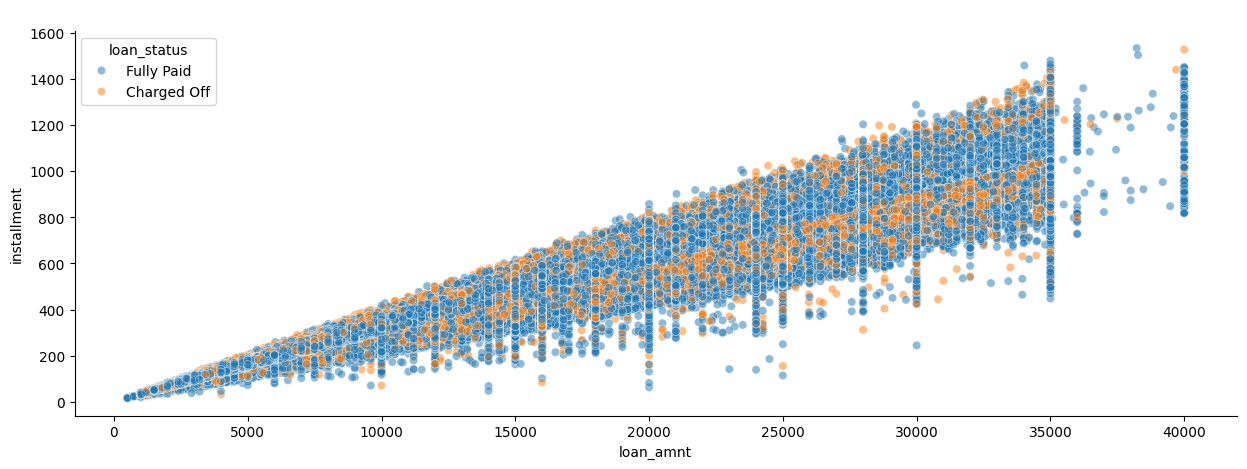

In [ ]:
plt.figure(figsize = (15,5))
sns.scatterplot(data = df, x = 'loan_amnt', y = 'installment', alpha = 0.5, hue = 'loan_status')
plt.title('Loan Amt Vs Installments',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
sns.despine()
plt.show()

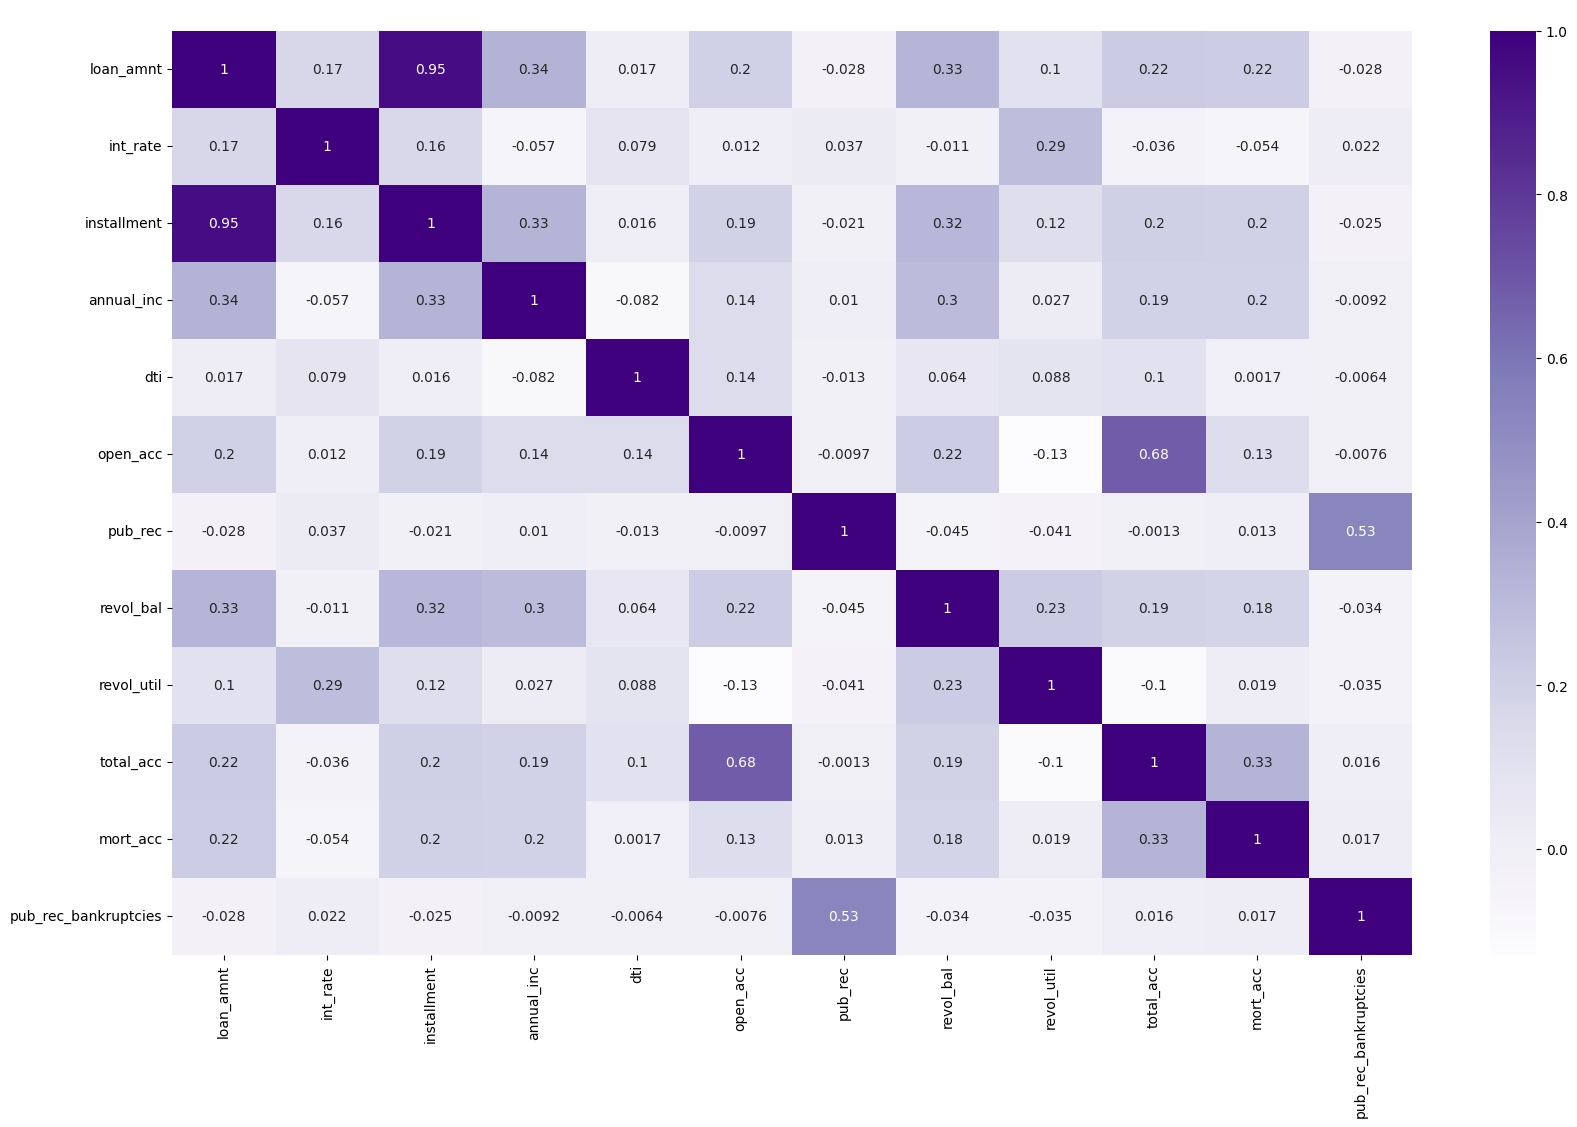

In [ ]:
#heatmap

plt.figure(figsize=(20,12))
sns.heatmap(num_cols.corr(), annot=True, cmap='Purples')
plt.title('Correlations - Heatmap',fontsize=12,fontfamily='serif',fontweight='bold',color='w')
plt.show()

Observation:


The correlation coefficient between 'loan_amnt' and 'installment' is quite high.

here exists a strong correlation between loan_amnt and installment, indicating that higher loan amounts correspond to larger installment payments.

variables total_acc and open_acc exhibit a significant correlation.


notable correlation between pub_rec_bankruptcies and pub_rec.


In [ ]:
(df['home_ownership'].value_counts(normalize=True)*100).to_frame()

,proportion
home_ownership,
MORTGAGE,50.084085
RENT,40.347953
OWN,9.531096
OTHER,0.028281
NONE,0.007828
ANY,0.000758


Observation

- Mortgage holders comprise the majority with approximately `50.08%`, indicating that a significant portion of individuals own homes through `Mortgage` agreements.
- `Renters` constitute a substantial portion, accounting for around `40.35%` of home ownership types. This suggests a sizable demographic of individuals who opt for renting rather than owning a home.

In [ ]:
pd.crosstab(df['grade'],df['loan_status'], normalize = 'index')

loan_status,Charged Off,Fully Paid
grade,,
A,0.062879,0.937121
B,0.125730,0.874270
C,0.211809,0.788191
D,0.288678,0.711322
E,0.373634,0.626366
F,0.427880,0.572120
G,0.478389,0.521611


Observation:

Grade 'A' borrowers demonstrate a significantly high likelihood of fully repaying their loans, with approximately 93.71% of loans being fully paid

In [ ]:
df[df['emp_title'] != 'No Employee Title']['emp_title'].value_counts().to_frame().head()

,count
emp_title,
Teacher,4389
Manager,4250
Registered Nurse,1856
RN,1846
Supervisor,1830


In [ ]:
df.groupby('emp_title')['loan_status'].count().sort_values(ascending=False).to_frame()[1:6]

,loan_status
emp_title,
Teacher,4389
Manager,4250
Registered Nurse,1856
RN,1846
Supervisor,1830


In [ ]:
#The Most afforded job titles are `Teachers & Managers`.

#Outlier Treatment:

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
df1 = df.copy()
def remove_outliers_zscore(df, threshold=2):
  z_scores = (df[numerical_cols] - df[numerical_cols].mean()) / df[numerical_cols].std()
  outliers = np.abs(z_scores) > threshold
  df_cleaned = df[~outliers.any(axis=1)]
  return df_cleaned
cleaned_df = remove_outliers_zscore(df1)
print(cleaned_df.shape)

(311392, 30)


In [ ]:
def clip_outliers_zscore(df, threshold=2):
  z_scores = (df[numerical_cols] - df[numerical_cols].mean()) / df[numerical_cols].std()
  clipped_values = df[numerical_cols].clip(df[numerical_cols].mean() - threshold * df[numerical_cols].std(),
                                             df[numerical_cols].mean() + threshold * df[numerical_cols].std(),
                                             axis=1)
  df_clipped = df.copy()
  df_clipped[numerical_cols] = clipped_values
  return df_clipped
clipped_df = clip_outliers_zscore(df1)
print(clipped_df.shape)

(396030, 30)


In [ ]:
data = cleaned_df.copy()
cp_data = clipped_df.copy()

#Encoding:

In [ ]:
data['loan_status']=data.loan_status.map({'Fully Paid':1, 'Charged Off':0})

data['initial_list_status']=data.initial_list_status.map({'w':0, 'f':1})

In [ ]:
def calc_vif(X):
    # Calculating the VIF
    vif=pd.DataFrame()
    vif['Feature']=X.columns
    vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
    vif['VIF']=round(vif['VIF'],2)
    vif=vif.sort_values(by='VIF',ascending=False)
    return vif

In [ ]:
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    chi2, p, dof, expected = chi2_contingency(pd.crosstab(data[col], data['loan_status']))
    if p > 0.05:
        print('>>>>>>> Independent feature - Not Significant:',col,' >> p value:',p)

>>>>>>> Independent feature - Not Significant: emp_title  >> p value: 0.5367121560200798
>>>>>>> Independent feature - Not Significant: title  >> p value: 1.0
>>>>>>> Independent feature - Not Significant: er_cr_line_m  >> p value: 0.2722117086158036
>>>>>>> Independent feature - Not Significant: state  >> p value: 0.76047808977373


In [ ]:
lt = data.drop(columns=['emp_title','title','sub_grade','er_cr_line_m','er_cr_line_y','initial_list_status',
                        'state','issue_month','issue_year','pub_rec','pub_rec_bankruptcies'],axis=1)

In [ ]:
#one hot encoding:
dummies=['zipcode', 'grade','purpose','home_ownership','verification_status','application_type']
ltd = pd.get_dummies(lt, columns=dummies, drop_first=True)*1

In [ ]:
#X and Y preperation:
X = ltd.drop(['loan_status'], axis=1)
y = ltd['loan_status']

In [ ]:
#train,test split:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y,random_state=42)

In [ ]:
#scaling:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
#model1:
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_train_pred = logreg_model.predict(X_train)
y_test_pred = logreg_model.predict(X_test)

In [ ]:
logreg_model.score(X_test, y_test) , logreg_model.score(X_test, y_test_pred)

(0.8934793429566948, 1.0)

Observations:

Can be a sign of overfitting due to the difference.

Train Accuracy : 0.89
Train F1 Score: 0.94
Train Recall Score: 1.0
Train Precision Score: 0.89

Test Accuracy : 0.89
Test F1 Score: 0.94
Test Recall Score: 1.0
Test Precision Score: 0.89


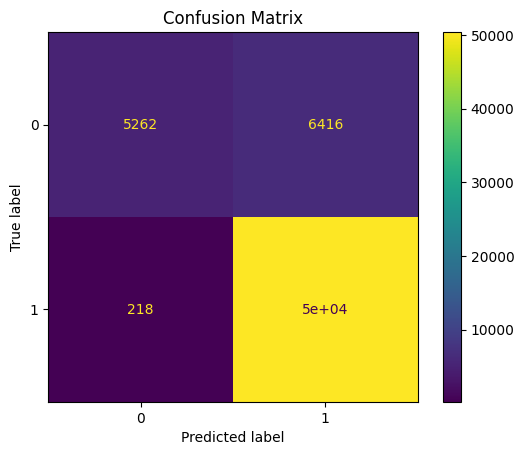

In [ ]:
print('Train Accuracy :', round(logreg_model.score(X_train, y_train), 2))
print('Train F1 Score:', round(f1_score(y_train, y_train_pred), 2))
print('Train Recall Score:', round(recall_score(y_train, y_train_pred), 2))
print('Train Precision Score:', round(precision_score(y_train, y_train_pred), 2))

print('\nTest Accuracy :', round(logreg_model.score(X_test, y_test), 2))
print('Test F1 Score:', round(f1_score(y_test, y_test_pred), 2))
print('Test Recall Score:', round(recall_score(y_test, y_test_pred), 2))
print('Test Precision Score:', round(precision_score(y_test, y_test_pred), 2))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       0.96      0.45      0.61     11678
           1       0.89      1.00      0.94     50601

    accuracy                           0.89     62279
   macro avg       0.92      0.72      0.78     62279
weighted avg       0.90      0.89      0.88     62279



Observations:

Class 0 recall looks to be low.

Since data is highly imbalanced we can use smote to maybe try to improve recall.

In [ ]:
#model 2:
sm=SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train,y_train.ravel())
model = LogisticRegression()
model.fit(X_train_res, y_train_res)
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

Train Accuracy : 0.79
Train F1 Score: 0.86
Train Recall Score: 0.79
Train Precision Score: 0.95

Test Accuracy : 0.8
Test F1 Score: 0.86
Test Recall Score: 0.79
Test Precision Score: 0.95


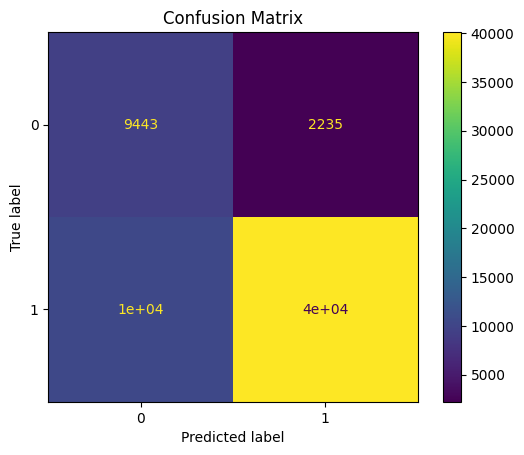

In [ ]:
print('Train Accuracy :', round(model.score(X_train, y_train), 2))
print('Train F1 Score:', round(f1_score(y_train, train_preds), 2))
print('Train Recall Score:', round(recall_score(y_train, train_preds), 2))
print('Train Precision Score:', round(precision_score(y_train, train_preds), 2))

print('\nTest Accuracy :', round(model.score(X_test, y_test), 2))
print('Test F1 Score:', round(f1_score(y_test, test_preds), 2))
print('Test Recall Score:', round(recall_score(y_test, test_preds), 2))
print('Test Precision Score:', round(precision_score(y_test, test_preds), 2))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_pred = test_preds
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.47      0.81      0.60     11678
           1       0.95      0.79      0.86     50601

    accuracy                           0.80     62279
   macro avg       0.71      0.80      0.73     62279
weighted avg       0.86      0.80      0.81     62279



> Smote model

* `Precision : 95%`  
* `Recall : 79%`
* `F1-score : 86%`
* `Accuracy : 80%`

Observations:

Model has significantly improved.



*   high recall score, successfully identifying 80% of actual defaulters

*   precision for the positive class (defaulters) is low; only 47% of predicted defaulters are actually defaulters

*   high recall and low precision indicate that while the model is effective at flagging most defaulters, it also results in many false positives.
*   low precision adversely affects the F1 score, reducing it to 60%, despite an overall accuracy of 80%. This highlights the trade-off between precision and recall in the model's performance.


*   model is good at catching most people who don't pay back their loans it catches 80% of them but precision is only 49%. Because of these mistakes, some people who deserve loans might not get them.



In [ ]:
#with regularisation:
lambd = np.arange(0.01, 1000, 10)

train_scores = []
test_scores = []

for lam in lambd:
    model = LogisticRegression(C = 1/lam)
    model.fit(X_train, y_train)

    tr_score = model.score(X_train, y_train)
    te_score = model.score(X_test, y_test)

    train_scores.append(tr_score)
    test_scores.append(te_score)

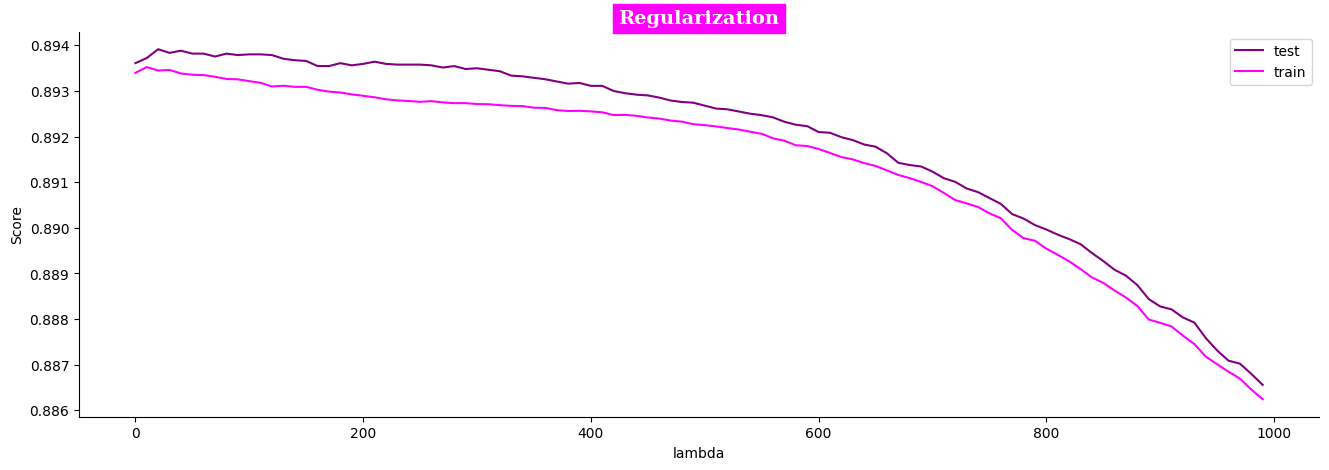

In [ ]:
#score vs lambda wrt regularisation:
ran = np.arange(0.01, 1000, 10)
plt.figure(figsize=(16,5))
sns.lineplot(x=ran,y=test_scores,color='purple',label='test')
sns.lineplot(x=ran,y=train_scores,color='magenta',label='train')
plt.title('Regularization',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='magenta',color='w')
plt.xlabel("lambda")
plt.ylabel("Score")
sns.despine()
plt.show()

In [ ]:
#Fit the model using best lambda
reg_model = LogisticRegression(C=0.03)
reg_model.fit(X_train, y_train)
y_reg_pred = reg_model.predict(X_test)
y_reg_pred_proba = reg_model.predict_proba(X_test)
model.score(X_test, y_test)

0.8865588721720002

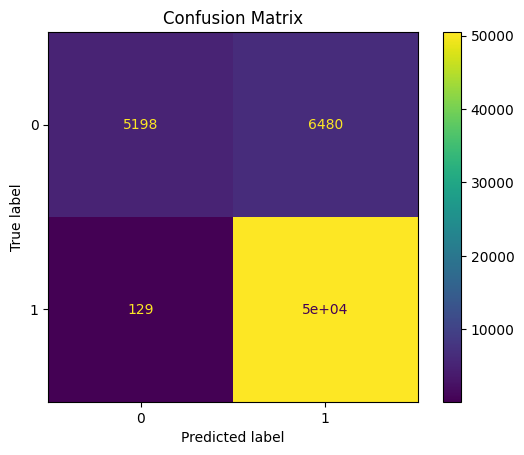

In [ ]:
cm = confusion_matrix(y_test, y_reg_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, y_reg_pred))

              precision    recall  f1-score   support

           0       0.98      0.45      0.61     11678
           1       0.89      1.00      0.94     50601

    accuracy                           0.89     62279
   macro avg       0.93      0.72      0.77     62279
weighted avg       0.90      0.89      0.88     62279



> Regularized model

* `Precision : 89%`  
* `Recall : 100%`
* `F1-score : 94%`
* `Accuracy : 89%`

In [ ]:
#Collect the model coefficients and print those in dataframe format
coeff_df = pd.DataFrame()
coeff_df['Features'] = X_train_res.columns
coeff_df['Weights'] = model.coef_[0]
coeff_df['ABS_Weights'] = abs(coeff_df['Weights'])
coeff_df = coeff_df.sort_values(['ABS_Weights'], ascending=False)
coeff_df

,Features,Weights,ABS_Weights
13,zipcode_11650,-2.205071,2.205071
20,zipcode_93700,-2.199511,2.199511
19,zipcode_86630,-2.187202,2.187202
12,zipcode_05113,1.349854,1.349854
15,zipcode_29597,1.345002,1.345002
2,int_rate,-0.647268,0.647268
5,dti,-0.533302,0.533302
24,grade_E,-0.464009,0.464009
4,annual_inc,0.460678,0.460678
1,term,-0.432346,0.432346


In [ ]:
model.intercept_

array([2.52298763])

# ROC AUC curve

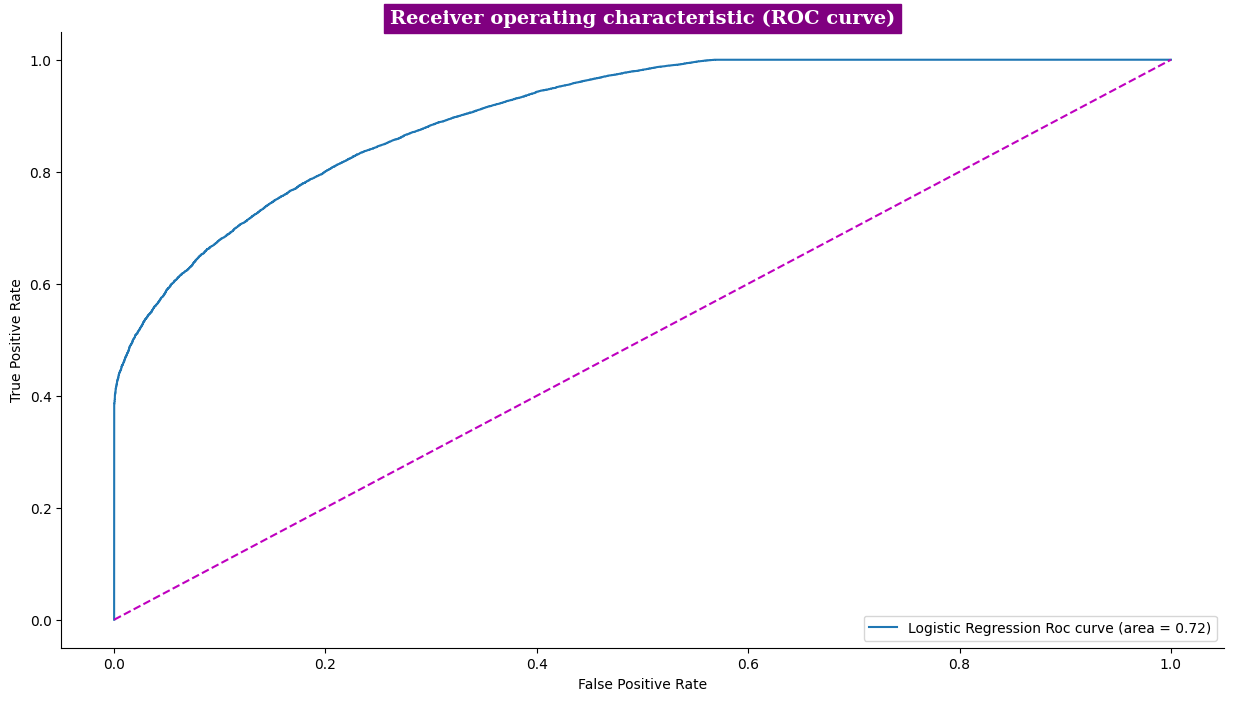

In [ ]:
logit_roc_auc = roc_auc_score(y_test,y_reg_pred)
fpr,tpr,thresholds = roc_curve(y_test,y_reg_pred_proba[:,1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(15,8))
plt.plot(fpr,tpr,label='Logistic Regression Roc curve (area = %0.2f)'% logit_roc_auc)
plt.plot([0,1],[0,1],'m--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC curve)',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='purple',color='w')
plt.legend(loc="lower right")
sns.despine()
plt.show()

Observations:

The ROC curve area, representing model performance, is 72%. This indicates that the model effectively distinguishes between classes 72% of the time.

Trade-off implies that while identifying more Fully Paid customers, there's a heightened risk of misclassifying Charged Off customers as Fully Paid, potentially leading to Non-Performing Assets.

**Solutions**:

- Reducing FPR while maintaining TPR is crucial to minimize misclassifications and associated risks.
- By shifting False Positives towards the left on the ROC curve, the model's overall performance, as measured by AUC, can improve.
- This improvement in AUC relies on maintaining a high True Positive Rate while reducing False Positives.


In [ ]:
logit_roc_auc

np.float64(0.7212805536942442)

In [ ]:
roc_auc = auc(fpr, tpr)
roc_auc

np.float64(0.9033906027220222)

#Precision-Recall Curve

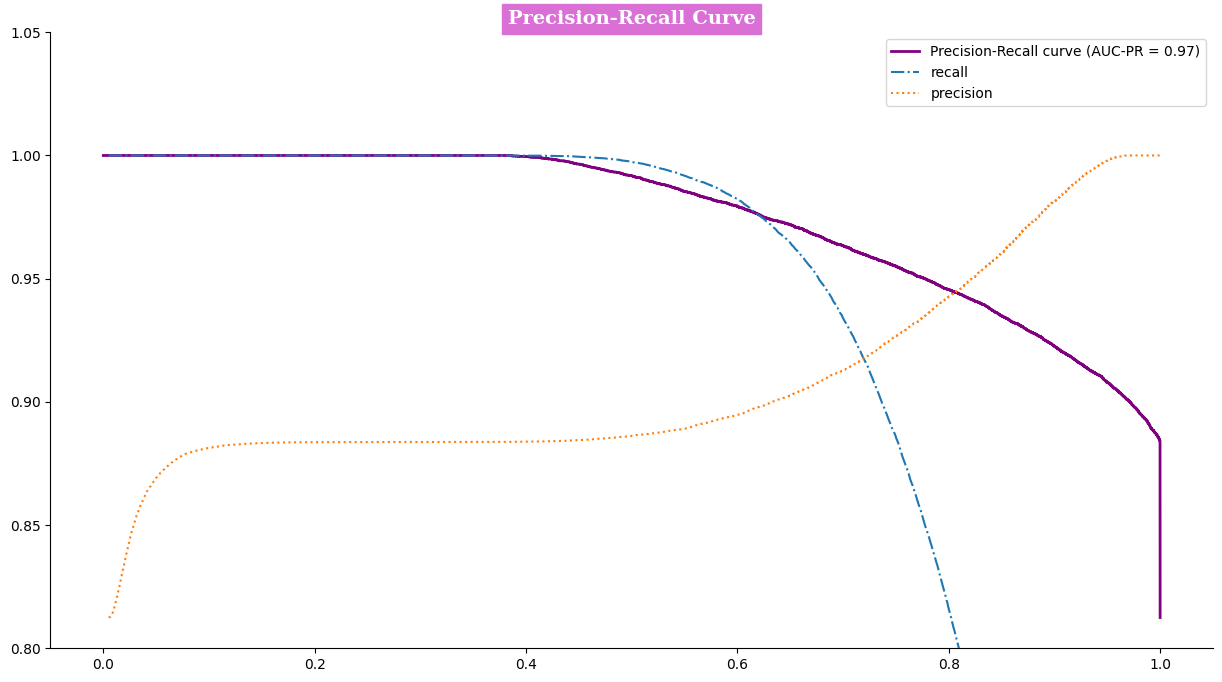

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_reg_pred_proba[:,1])

average_precision = average_precision_score(y_test, y_reg_pred_proba[:,1])


plt.figure(figsize=(15,8))
plt.plot(recall, precision, color='purple', lw=2, label=f'Precision-Recall curve (AUC-PR = {average_precision:.2f})')

plt.plot(thresholds, recall[0:thresholds.shape[0]], label='recall',linestyle='-.')
plt.plot(thresholds, precision[0:thresholds.shape[0]], label='precision',linestyle='dotted')

plt.ylim([0.8, 1.05])
plt.title('Precision-Recall Curve',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='orchid',color='w')
plt.legend(loc='upper right')
sns.despine()
plt.show()

In [ ]:
auc(recall, precision)

np.float64(0.9749258428878598)

Observations:

The Area Under the Curve for the precision-recall curve is 0.975.Suggests that the model achieves excellent performance in distinguishing between positive and negative classes.


In [ ]:
#using class weights:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')

lr_model = lr.fit(X_train, y_train)

print(classification_report(y_test, lr_model.predict(X_test)))

cm_bal = confusion_matrix(y_test, lr_model.predict(X_test))
cm_bal_df = pd.DataFrame(cm_bal, index=['Defaulter','Fully paid'], columns=['Defaulter','Fully paid'])
cm_bal_df

              precision    recall  f1-score   support

           0       0.47      0.81      0.60     11678
           1       0.95      0.79      0.86     50601

    accuracy                           0.79     62279
   macro avg       0.71      0.80      0.73     62279
weighted avg       0.86      0.79      0.81     62279



,Defaulter,Fully paid
Defaulter,9468,2210
Fully paid,10586,40015


Above lools like a more balanced model.
* `Precision : 95%`  
* `Recall : 79%`
* `F1-score : 86%`
* `Accuracy : 79%`


In [ ]:
#above lools like a more balanced model.

Questions and Answers:

What percentage of customers have fully paid their Loan Amount?
---80.26% of customers have fully paid their Loan Amount.

Comment about the correlation between Loan Amount and Installment features.
---very high (0.97).

The majority of people have home ownership as 'Mortage'.

People with grades ‘A’ are more likely to fully pay their loan. (T/F)

---True.

Name the top 2 afforded job titles.
---Teacher & Manager.

Thinking from a bank's perspective, which metric should our primary focus be on..
F1 score, with keeping in mind that recall is also necessary for the current case. But there will always be a tradeoff between precision and recall.

How does the gap in precision and recall affect the bank?

---the gap between precision and recall will affect the bank. As the gap widens, there will be increase in incorrect predictions.Good precision means less False Positive which means Less NPA loan accounts.Good recall means less False Negatives. which means not loosing on good customer.

Which were the features that heavily affected the outcome?

---Address,annual income,Grade seem to be very important in this case.
---term,revol_bal,dti,int_rate have high weights.

Will the results be affected by geographical location? (Yes/No) *
---Yes, the pincode extracted showed that its a very good feature and has an impact.

#Recommendations:

**Curate a Loan Approval Stratgey**:


--Focus on maxmizing f1 score overall, while managing the recall-precison trade-off.

**Model improvement**:


-- Complex classifiers like Random forest may help with model performance.

Policies derived from Insights:
--Scrutinize loans with lower grades more rigorously and consider adjusting interest rates to compensate for higher risk.

--Areas of high-profile zip-codes(more business) target them.


(3 models have been established in this case, choosing the 2nd or 3rd depends on the requirement)

